## simplified anoGAN

similar to v1 works well
dava vice embedingu s ohledem na to co ma na vstupu - to je parada

## Depencencies

In [1]:
from pathlib import Path
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [3]:
sys.path.append(os.path.abspath(".."))

## DATA

In [4]:
from anomaly_detection.utils.load_sam_data import load_dataset
from anomaly_detection.utils.plotting_styles import apply_global_style
from anomaly_detection.utils.autoencoders import minmax_scale_per_sample
from anomaly_detection.utils.autoencoders import drop_empty_histograms

data_dir = "FJ"
dataset = load_dataset(data_dir)
full_dataset = np.array(dataset)
full_dataset = minmax_scale_per_sample(full_dataset)

dataset_no_outs = drop_empty_histograms(full_dataset)

Loading data from: C:\Users\hrdyj\coding\vyzkumak\data\FJ\FI01X1\FI01X1_ch
Dropped indexes [8, 15, 188, 214, 263, 268, 533, 546]


<BarContainer object of 96 artists>

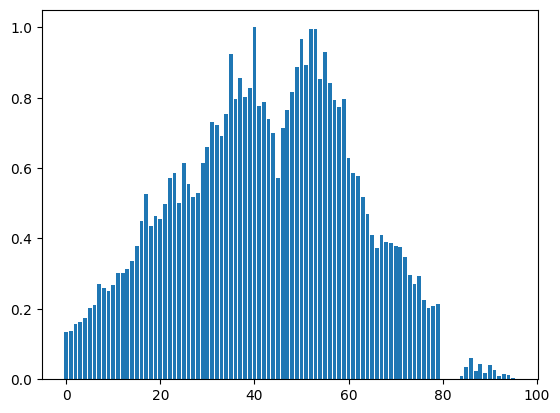

In [5]:
plt.bar(range(96), full_dataset[499])

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(dataset_no_outs, shuffle=True, train_size=0.8, random_state=42)

In [7]:
dataset_no_outs = torch.from_numpy(dataset_no_outs)
X_train = torch.from_numpy(X_train)
X_test = torch.from_numpy(X_test)
full_dataset = torch.from_numpy(full_dataset)

dataset_no_outs = dataset_no_outs.to(torch.float32)
X_train = X_train.to(torch.float32)
X_test = X_test.to(torch.float32)
full_dataset = full_dataset.to(torch.float32)

# Models and testing

In [8]:
pt = torch.zeros(20).reshape(1,1,20)
generator = nn.Sequential(
                nn.ConvTranspose1d(in_channels=1, out_channels=4, kernel_size=4, stride=1),
                nn.ReLU(),
                nn.ConvTranspose1d(in_channels=4, out_channels=16, kernel_size=4, stride=2),
                nn.ReLU(),
                nn.ConvTranspose1d(in_channels=16, out_channels=16, kernel_size=4, stride=3))
torch.flatten(generator(pt)).shape

torch.Size([2320])

In [9]:
LATENT_DIM = 22

In [10]:
type(dataset[4])

numpy.ndarray

In [11]:
pt = full_dataset[22].reshape(1,1,96)
enc = nn.Sequential(
       nn.Conv1d(in_channels=1, out_channels=2, kernel_size=8, padding=1),
       nn.Conv1d(in_channels=2, out_channels=4, kernel_size=6, padding=1),
       nn.Conv1d(in_channels=4, out_channels=8, kernel_size=3, padding=1),
       nn.Conv1d(in_channels=8, out_channels=4, kernel_size=3, padding=1),
       nn.Conv1d(in_channels=4, out_channels=2, kernel_size=3, stride=2, padding=1),
       nn.Conv1d(in_channels=2, out_channels=1, kernel_size=3, stride=2, padding=1), # output 1, 1, 22
)
enc(pt).shape

torch.Size([1, 1, 22])

In [12]:
class Generator(nn.Module):
    """Generates new data from the latent space"""
    def __init__(self):
        super(Generator, self).__init__()
        self.conv1 = nn.ConvTranspose1d(in_channels=1, out_channels=4, kernel_size=4, stride=1)
        self.conv2 = nn.ConvTranspose1d(in_channels=4, out_channels=16, kernel_size=4, stride=2)
        self.conv3 = nn.ConvTranspose1d(in_channels=16, out_channels=16, kernel_size=4, stride=3)
        self.fc1 =  nn.Linear(2512, 1600)
        self.fc2 =  nn.Linear(1600, 512)
        self.fc3 = nn.Linear(512, 256)
        self.fc4 = nn.Linear(256, 128)
        self.fc5 = nn.Linear(128, 96)

    
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))
        x = F.sigmoid(self.fc5(x))
        return x

class Discriminator(nn.Module):
    """Takes real data and input from Generator predicts real/fake class"""
    def __init__(self):
        super(Discriminator, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=4, kernel_size=8, padding=1)
        self.conv2 = nn.Conv1d(in_channels=4, out_channels=8, kernel_size=6, padding=1)
        self.conv3 = nn.Conv1d(in_channels=8, out_channels=12, kernel_size=3, stride=2, padding=1)
        self.conv4 = nn.Conv1d(in_channels=12, out_channels=16, kernel_size=3, stride=2, padding=1)
        self.fc1 = nn.Linear(in_features=352, out_features=256)
        self.fc2 = nn.Linear(in_features=256, out_features=128)
        self.fc3 = nn.Linear(in_features=128, out_features=32)

    def forward(self, x, return_features=False):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = x.view(x.size(0), -1) # zmenit na torch flatten
        x = F.relu(self.fc1(x))
        features = torch.relu(self.fc2(x))
        out = F.relu(features)
        
        if return_features:
            return out, features
        else:
            return out

class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()
        self.conv_block = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(16),
            nn.LeakyReLU(0.2),
            
            nn.Conv1d(16, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.2),
        )

        self.flatten_dim = 32 * 24 
        
        self.fc_block = nn.Sequential(
            nn.Linear(self.flatten_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 22)
        )

    def forward(self, x):
        x = self.conv_block(x)
        x = torch.flatten(x, start_dim=1)
        x = self.fc_block(x)
        return x


In [13]:
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import DataLoader

class HistDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        hist = self.data[idx]
        hist = torch.tensor(hist, dtype=torch.float32)
        return hist

## Training params

In [14]:
batch_size = 32

torch_df = HistDataset(full_dataset)
dataloader = DataLoader(torch_df, batch_size=batch_size, shuffle=True)

gen = Generator()
critic = Discriminator()
encoder = Encoder()

latent_dim = 22
lr = 1e-4
batch_size = 32
num_epochs_gan = 100
num_epochs_enc = 100
critic_iterations = 5
lambda_gp = 10.0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

optimizer_G = torch.optim.Adam(gen.parameters(), lr=lr, betas=(0.5, 0.9))
optimizer_C = torch.optim.Adam(critic.parameters(), lr=lr, betas=(0.5, 0.9))
optimizer_E = torch.optim.Adam(encoder.parameters(), lr=lr)

In [15]:
def gradient_penalty(critic, real, fake):
    batch_size = real.size(0)

    eps = torch.rand(batch_size, 1, 1, device=real.device)

    # (B,1,1) to (B,1,96)
    x_hat = eps * real + (1 - eps) * fake
    x_hat.requires_grad_(True)

    d_hat = critic(x_hat)

    gradients = torch.autograd.grad(
        outputs=d_hat,
        inputs=x_hat,
        grad_outputs=torch.ones_like(d_hat),
        create_graph=True,
        only_inputs=True
    )[0]

    gradients = gradients.view(batch_size, -1)
    gp = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return gp


## Training

In [16]:
gen.train()
critic.train()

for epoch in range(num_epochs_gan):
    for real_data in dataloader:
        real_data = real_data.to(device)
        batch_size_gan_training = real_data.shape[0]

        # ---- Critic update ----
        for _ in range(critic_iterations):
            z = torch.randn(batch_size_gan_training, 1, latent_dim, device=device)
            fake_data = gen(z).detach()

            fake_data = fake_data.reshape(batch_size_gan_training, 1, 96)
            real_data = real_data.reshape(batch_size_gan_training, 1, 96)

            loss_C = (
                critic(fake_data).mean() - critic(real_data).mean()
            )

            gp = gradient_penalty(critic, real_data, fake_data)
            loss_C_total = loss_C + lambda_gp * gp

            optimizer_C.zero_grad()
            loss_C_total.backward()
            optimizer_C.step()

        # ---- Generator update ----
        z = torch.randn(batch_size_gan_training, 1, latent_dim, device=device)
        fake_data = gen(z)
        fake_data = fake_data = fake_data.reshape(batch_size_gan_training, 1, 96)

        loss_G = -critic(fake_data).mean()

        optimizer_G.zero_grad()
        loss_G.backward()
        optimizer_G.step()

    if epoch % 20 == 0:
        print(f"Epoch {epoch}/{num_epochs_gan} | "
              f"D: {loss_C.item():.4f} | G: {loss_G.item():.4f}")


C:\Users\hrdyj\AppData\Local\Temp\ipykernel_37280\2451661108.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  hist = torch.tensor(hist, dtype=torch.float32)


Epoch 0/100 | D: -0.0027 | G: -0.0099
Epoch 20/100 | D: -0.0111 | G: -0.0224
Epoch 40/100 | D: -0.0144 | G: -0.0310
Epoch 60/100 | D: -0.0045 | G: -0.0450
Epoch 80/100 | D: 0.0020 | G: -0.0453


In [17]:
for p in gen.parameters():
    p.requires_grad = False

for p in critic.parameters():
    p.requires_grad = False

In [18]:
batch_size = 32

In [19]:
alpha = 0.9
beta = 0.1

encoder.train()

for epoch in range(num_epochs_enc):
    for x in dataloader:
        batch_size_encoder_training = x.shape[0]
        x = x.to(device)
        x = x.reshape(batch_size_encoder_training, 1, 96)

        z = encoder(x)
        z = z.reshape(batch_size_encoder_training, 1, z.shape[1])
        x_hat = gen(z)

        # reconstruction loss
        loss_rec = torch.mean(torch.abs(x - x_hat))

        # feature matching
        _, feat_x = critic(x, return_features=True)
        x_hat = x_hat.reshape(batch_size_encoder_training, 1, 96)
        _, feat_x_hat = critic(x_hat, return_features=True)

        loss_feat = torch.mean(torch.abs(feat_x - feat_x_hat))

        loss_E = alpha * loss_rec + beta * loss_feat

        optimizer_E.zero_grad()
        loss_E.backward()
        optimizer_E.step()

    if epoch % 10 == 0:
        print(f"[ENC] Epoch {epoch}/{num_epochs_enc} | "
              f"Rec: {loss_rec.item():.4f} | Feat: {loss_feat.item():.4f}")


C:\Users\hrdyj\AppData\Local\Temp\ipykernel_37280\2451661108.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  hist = torch.tensor(hist, dtype=torch.float32)


[ENC] Epoch 0/100 | Rec: 0.0950 | Feat: 0.0023
[ENC] Epoch 10/100 | Rec: 0.0851 | Feat: 0.0020
[ENC] Epoch 20/100 | Rec: 0.0817 | Feat: 0.0020
[ENC] Epoch 30/100 | Rec: 0.1136 | Feat: 0.0035
[ENC] Epoch 40/100 | Rec: 0.0798 | Feat: 0.0016
[ENC] Epoch 50/100 | Rec: 0.0817 | Feat: 0.0018
[ENC] Epoch 60/100 | Rec: 0.0881 | Feat: 0.0023
[ENC] Epoch 70/100 | Rec: 0.0883 | Feat: 0.0022
[ENC] Epoch 80/100 | Rec: 0.0837 | Feat: 0.0021
[ENC] Epoch 90/100 | Rec: 0.0888 | Feat: 0.0021


In [20]:
def anomaly_score(x):
    with torch.no_grad():
        encoder.eval()
        z = encoder(x)
        z = z.reshape(1, 1, z.shape[1])
        x_hat = gen(z)
        x_hat = x_hat.reshape(1, 1, 96)
        
        rec = torch.mean(torch.abs(x - x_hat), dim=(1,2))
        _, fx = critic(x, return_features=True)
        _, fx_hat = critic(x_hat, return_features=True)

        feat = torch.mean(torch.abs(fx - fx_hat), dim=1)
        return alpha * rec + beta * feat


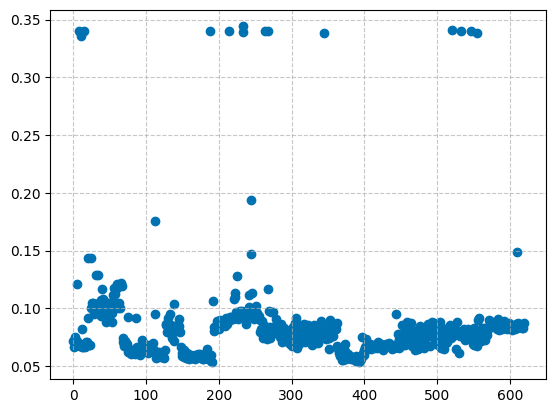

In [21]:
scores = []
for data in full_dataset:
    scores.append(anomaly_score(data.reshape(1, 1, 96)))
apply_global_style()
plt.scatter(range(len(scores)), scores)

In [22]:
[idx for idx, sc in enumerate(scores) if sc > 0.24]

[8, 11, 15, 188, 214, 233, 234, 263, 268, 344, 520, 533, 546, 555]

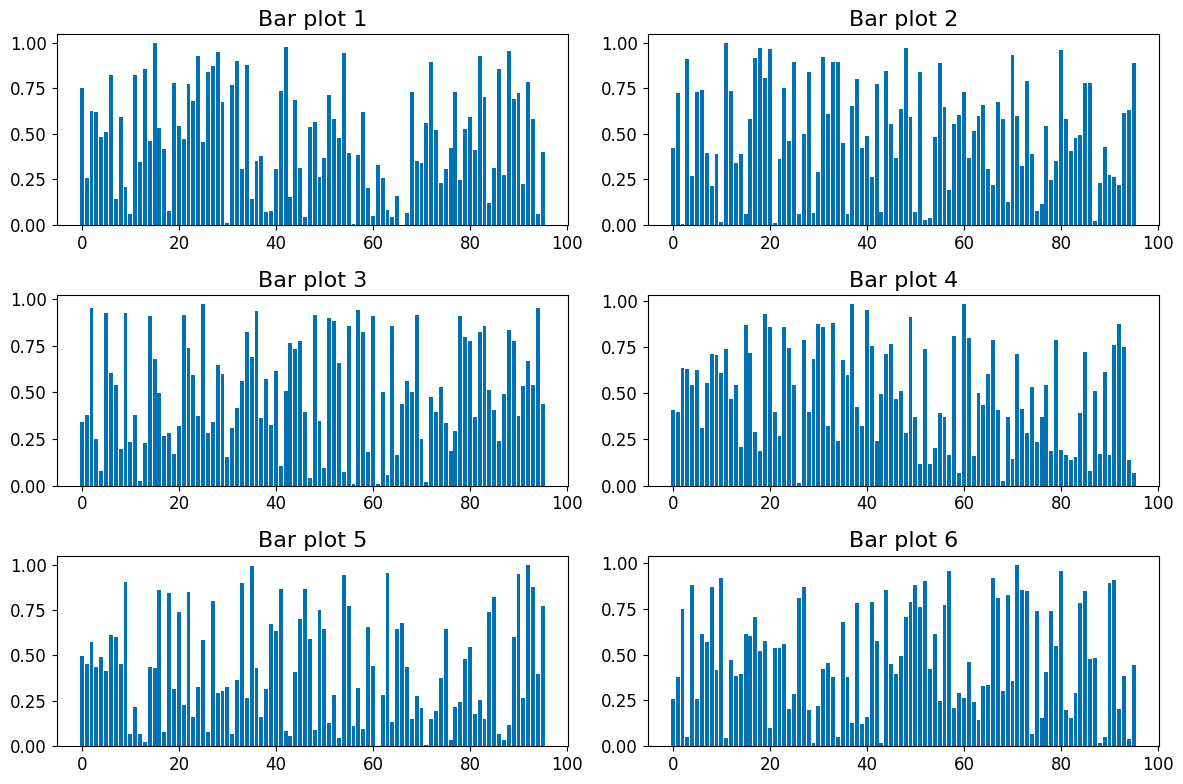

In [23]:
randoms = [torch.rand(96) for _ in range(6)]

fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (ax, data) in enumerate(zip(axes, randoms)):
    ax.bar(range(len(data)), data)
    ax.set_title(f"Bar plot {i+1}")

plt.tight_layout()
plt.show()

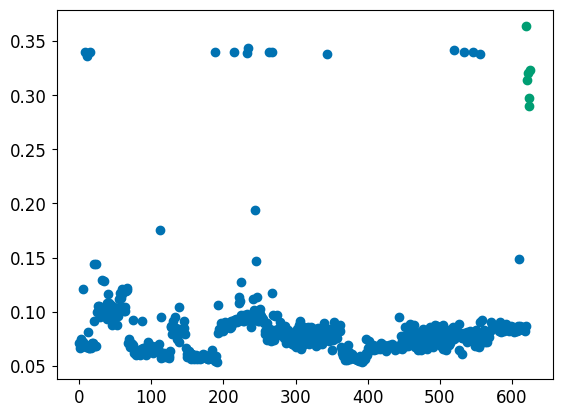

In [24]:
out_scores = []
for out in randoms:
    score = anomaly_score(out.reshape(1,1,96))
    out_scores.append(score)
plt.scatter(range(len(scores)), scores)
plt.scatter(range(len(scores), len(scores) + len(out_scores)), out_scores)
plt.show()

# Evaluation and results

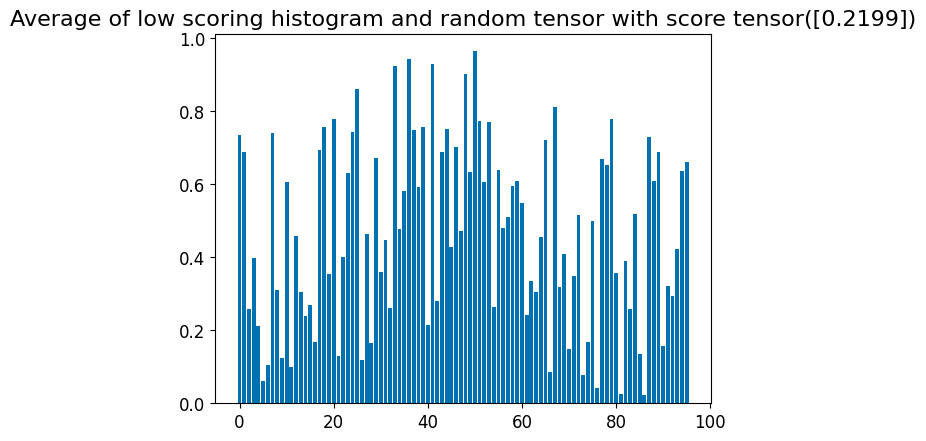

In [25]:
new_pt = (1.6*torch.rand(96) + 0.4*full_dataset[90])/2
plt.bar(range(len(new_pt)), new_pt)
score = anomaly_score(new_pt.reshape(1,1,96))
plt.title(f"Average of low scoring histogram and random tensor with score {score}")
plt.show()

In [26]:
[id for id, s in enumerate(scores) if s < 0.25 and s > 0.18]

[244]

<BarContainer object of 96 artists>

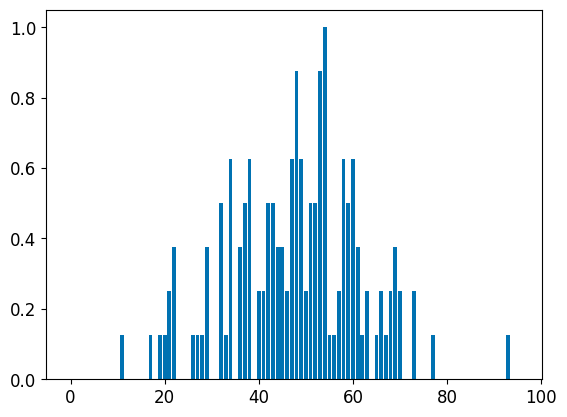

In [27]:
plt.bar(range(len(full_dataset[244])), full_dataset[244])

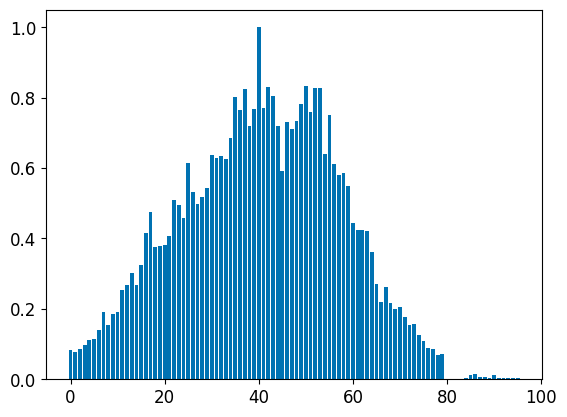

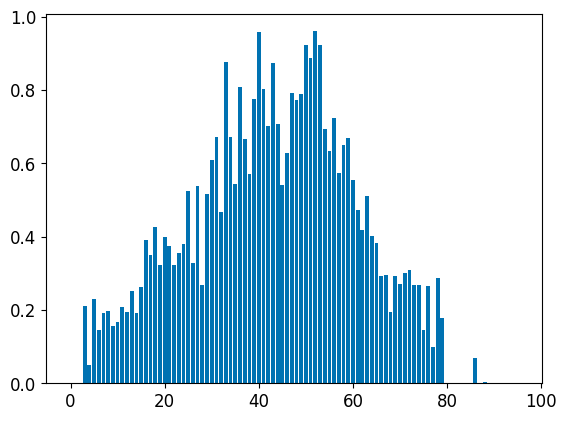

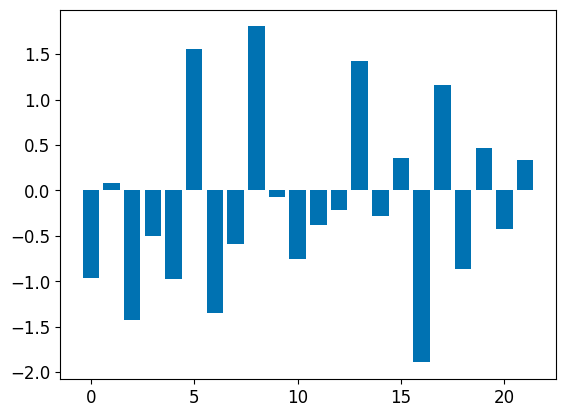

In [28]:
gen.eval()
encoder.eval()

orig_hist = full_dataset[80]
embed = encoder(orig_hist.reshape(1,1,96)).detach()
reconstruct = gen(embed.reshape(1,1,22)).detach().numpy().squeeze()

plt.bar(range(len(orig_hist)), orig_hist)
plt.show()

plt.bar(range(len(reconstruct)), reconstruct)
plt.show()

plt.bar(range(len(embed.numpy().squeeze())), embed.numpy().squeeze())
plt.show()

In [ ]:
# from anomaly_detection.config.paths import CHECKPOINT_DIR

# torch.save({
#     "generator": gen.state_dict(),
#     "discriminator": critic.state_dict(),
#     "encoder": encoder.state_dict(),
#     "config": {
#         "input_dim": 96,
#         "latent_dim": 22,
#     }
# }, f"{CHECKPOINT_DIR}/f_anogan_symmetrical.pth")